# Анализ и прогнозирование временных рядов методами искусственного интеллекта

## **Практическая работа 5. Поиск типичных подпоследовательностей временного ряда.**

In [2]:
%load_ext autoreload
%autoreload 2

Импорт библиотек и модулей

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from modules.snippets import *
from scipy import signal
from stumpy import snippets
from tqdm import tqdm

### **Задача 1. Поиск сниппетов одномерного временного ряда**

В первой задаче необходимо выполнить поиск сниппетов одномерного временного ряда. Расмотрите приведенный ниже пример использования алгоритма SnipperFinder и визуализации полученных результатов для искуственного врменного ряда.

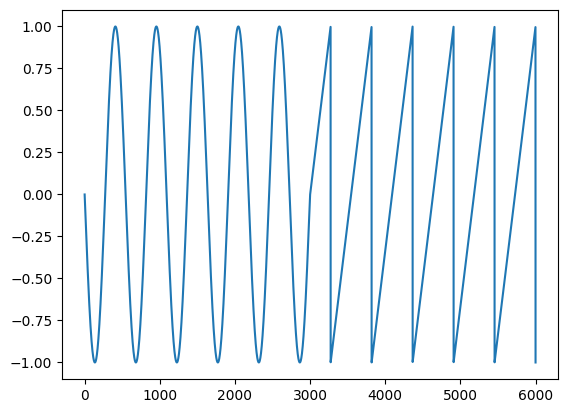

In [6]:
#Создание искусственного временного ряда
t = np.linspace(np.pi, 6 * 2 * np.pi, 3000)
ts = np.concatenate([np.sin(t), signal.sawtooth(t)])
plt.plot(ts)

In [7]:
#Поиск сниппетов
snp = snippets(ts, 600, 2, percentage=0.5)

600


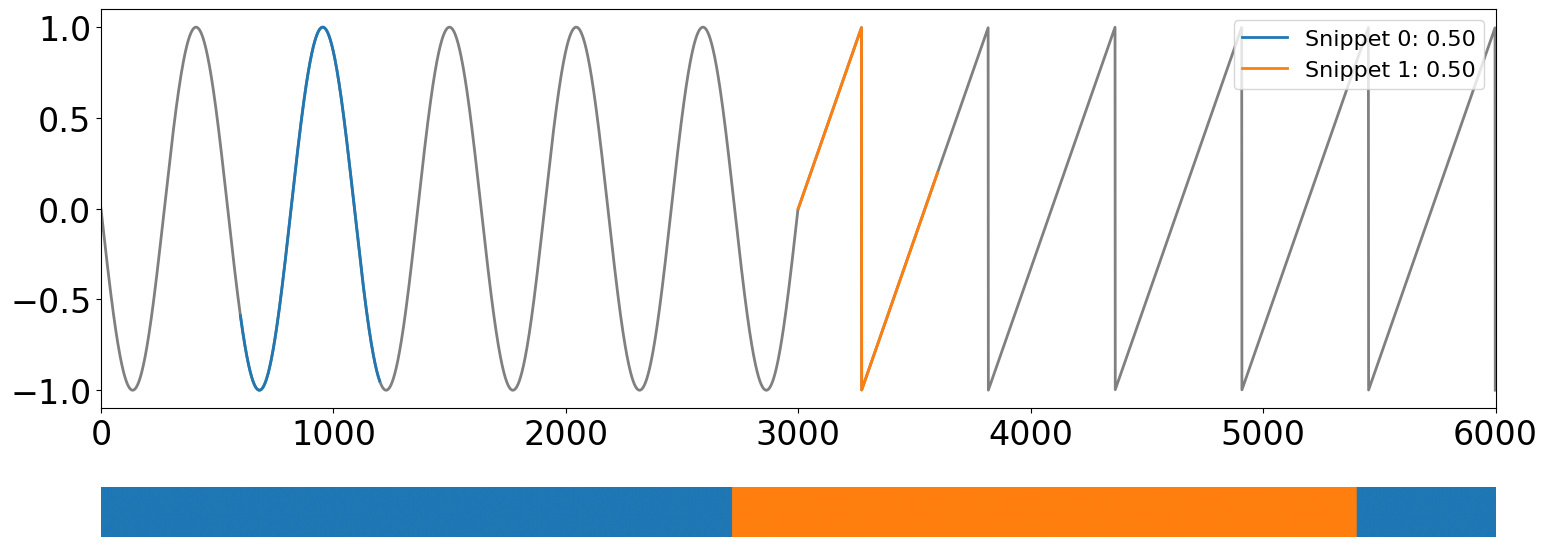

<Axes: >

In [8]:
#Визуализация результатов
plot_snippets(ts, snp)

Далее вам предстоит самостоятельно выполнить поиск top-$k$ типичных подпоследовательностей временного ряда (сниппетов) с помощью алгоритма SnippetFinder на наборе данных PAMAP. Описание набора данных находится в [README-файле](datasets/PAMAP/readme.md).

Выполните считывание временного ряда **показаний гироскопа на оси «Y» (угол тангажа) на временном интервале от 1790 сек. до 1930 сек.** (используя колонку с временными метками) из файла *PAMAP.txt*, который располагается в директории *./datasets/PAMAP*. Затем выполните поиск сниппетов с помощью функции `snippets()` из библиотеки stumpy. Затем визуализируйте полученные результаты, используя функцию `plot_snippets()` из модуля snippets.py.

In [10]:
ts_url = './datasets/PAMAP/PAMAP.txt'

ts_origin = np.loadtxt(ts_url)

In [11]:
ts_origin.shape

(20, 146000)

In [12]:
# 1 timestamp (s)

timestamp = ts_origin[0]
timestamp

array([ 505.71,  505.72,  505.73, ..., 2305.68, 2305.69, 2305.7 ])

In [13]:
time_range = np.where((timestamp >= 1790.0) & (timestamp <= 1930.0))
timestamp[time_range]

array([1795.71, 1795.72, 1795.73, ..., 1929.98, 1929.99, 1930.  ])

In [14]:
np.sum(np.isnan(timestamp[time_range]))

0

In [15]:
# 11-13 3D-gyroscope data (rad/s)
# Since data is given every 0.01s
ts = ts_origin[12][time_range]

In [16]:
ts.shape

(13430,)

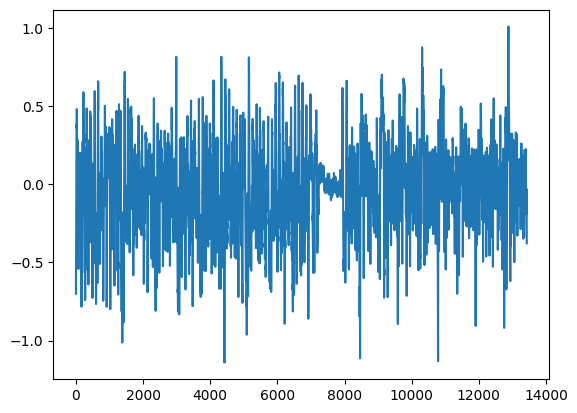

In [17]:
plt.plot(ts)

In [18]:
snp = snippets(ts, 600, 2, percentage=0.5)

Выполните визулизацию временного ряда и найденных сниппетов с помощью функции `plot_snippets()` из модуля snippets.py.

600


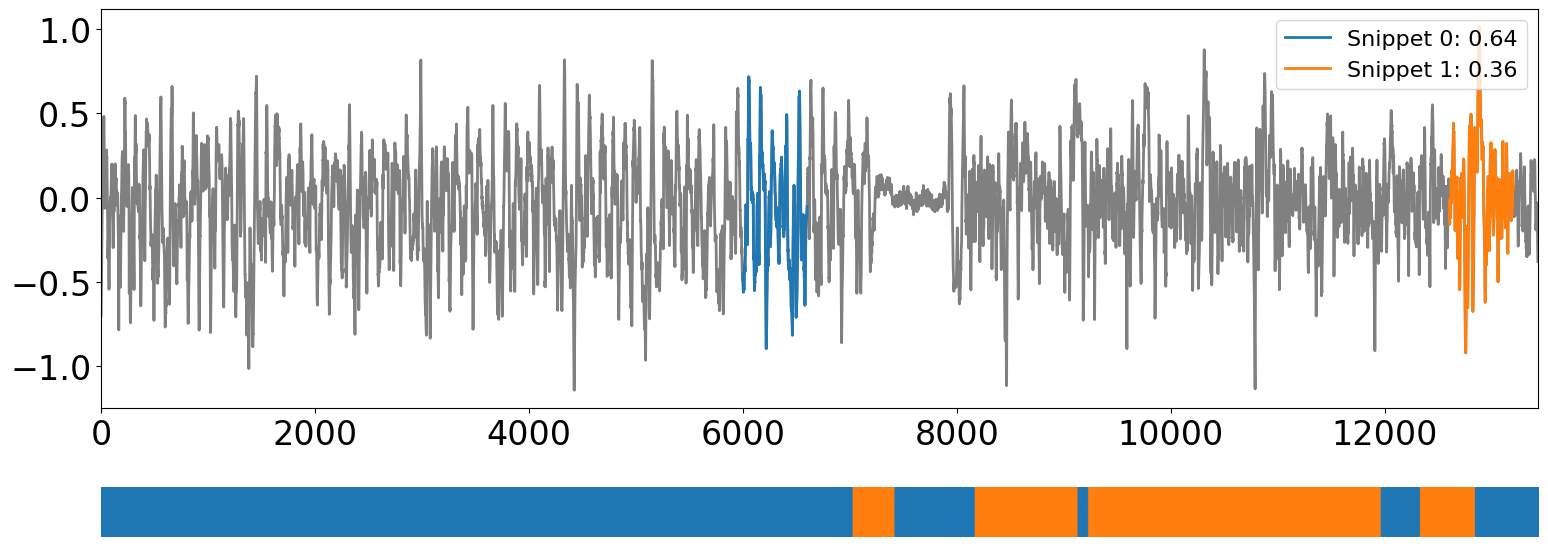

<Axes: >

In [20]:
plot_snippets(ts, snp)

Оцените точность разметки, полученной при помощи сниппетов, используя исходные данные об активностях в ряде.

In [22]:
snp[5]

array([[    0,     0,  7020],
       [    0,  7410,  8160],
       [    0,  9120,  9219],
       [    0, 11952, 12319],
       [    1,  7020,  7410],
       [    1,  8160,  9120],
       [    1,  9219, 11952],
       [    1, 12319, 12831]])

In [23]:
activityID = ts_origin[1][time_range]
activityID

array([12., 12., 12., ..., 13., 13., 13.])

In [24]:
activityID.shape

(13430,)

In [25]:
# 12 ascending stairs
# 13 descending stairs
labels = np.unique(activityID)
labels

array([12., 13.])

In [26]:
predicted = np.full_like(activityID, labels[0], dtype=int)

for segment in snp[5]:
    index, start, end = segment
    predicted[start:end] = labels[index]

predicted

array([12, 12, 12, ..., 12, 12, 12])

In [27]:
index_min = np.min(snp[5][:, 1])
index_max = np.max(snp[5][:, 2])
index_min, index_max

(0, 12831)

In [28]:
np.mean(activityID[index_min:index_max] == predicted[index_min:index_max])

0.8846543527394591

❓ Проанализируйте и изложите содержательный смысл полученных результатов.

Метрика аккуратности составляет 88%, что говорит об эффективном разделении временного ряда на семантические сегменты с помощью сниппетов.

### Задача 2. Разметка многомерного временного ряда

Выполните разметку многомерного временно ряда, используя **показания гироскопа по всем трем осям** из набора данных PAMAP. Используйте тот же временной интервал, что и в задаче 1. Итоговую разметку получите в результате голосования большинством.

In [32]:
# 11-13 3D-gyroscope data (rad/s)
# Since data is given every 0.01s
ts_x = ts_origin[11][time_range]
ts_y = ts_origin[12][time_range]
ts_z = ts_origin[13][time_range]

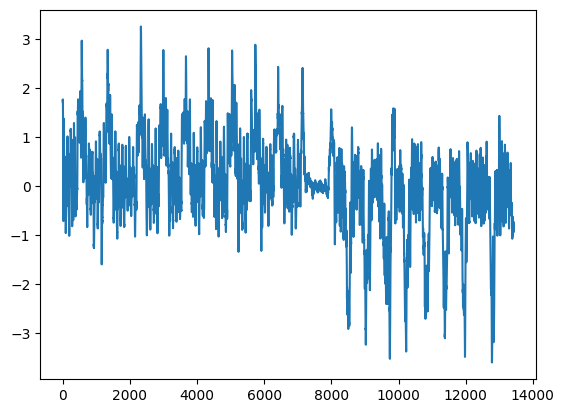

In [33]:
plt.plot(ts_x)

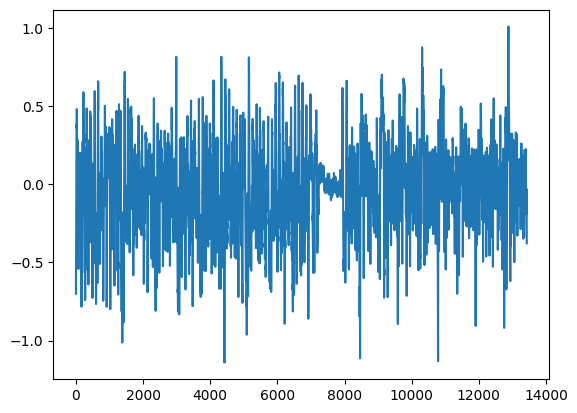

In [34]:
plt.plot(ts_y)

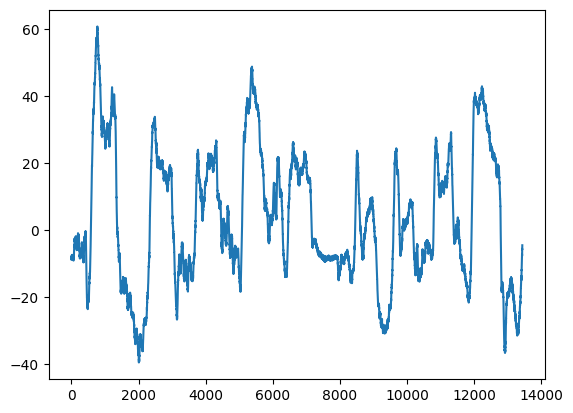

In [35]:
plt.plot(ts_z)

In [36]:
snp_x = snippets(ts_x, 600, 2, percentage=0.5)

In [37]:
snp_y = snippets(ts_y, 600, 2, percentage=0.5)

In [38]:
snp_z = snippets(ts_z, 600, 2, percentage=0.5)

600


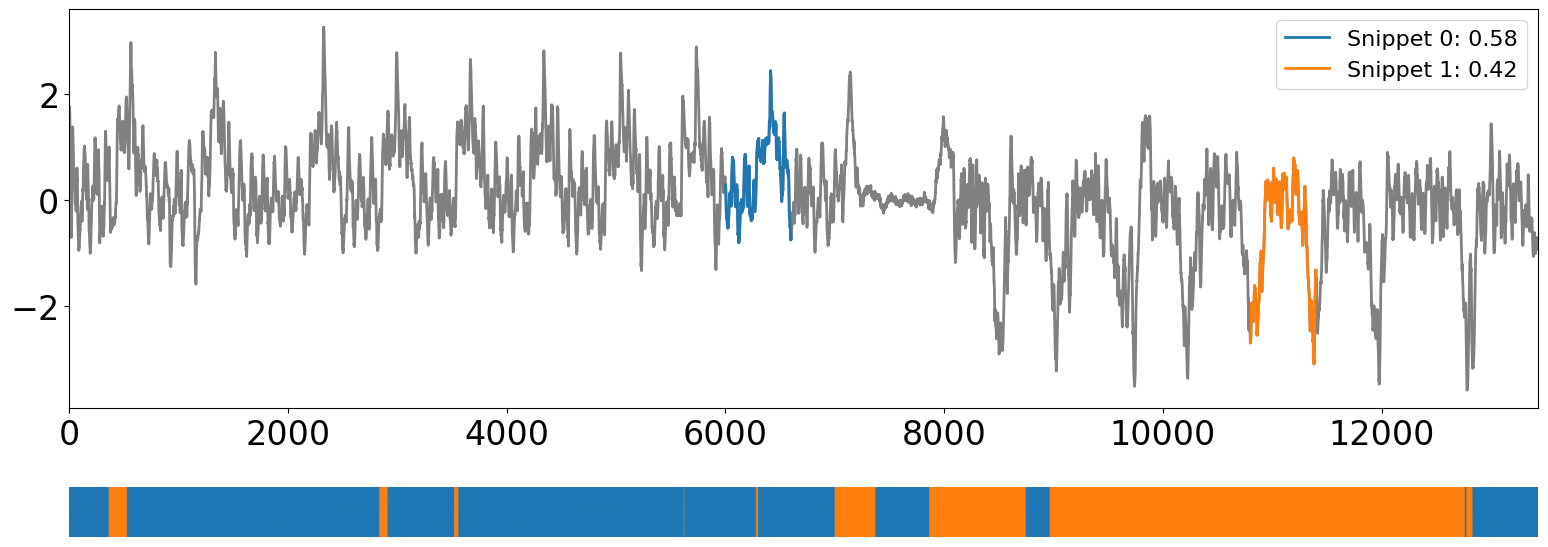

<Axes: >

In [39]:
plot_snippets(ts_x, snp_x)

600


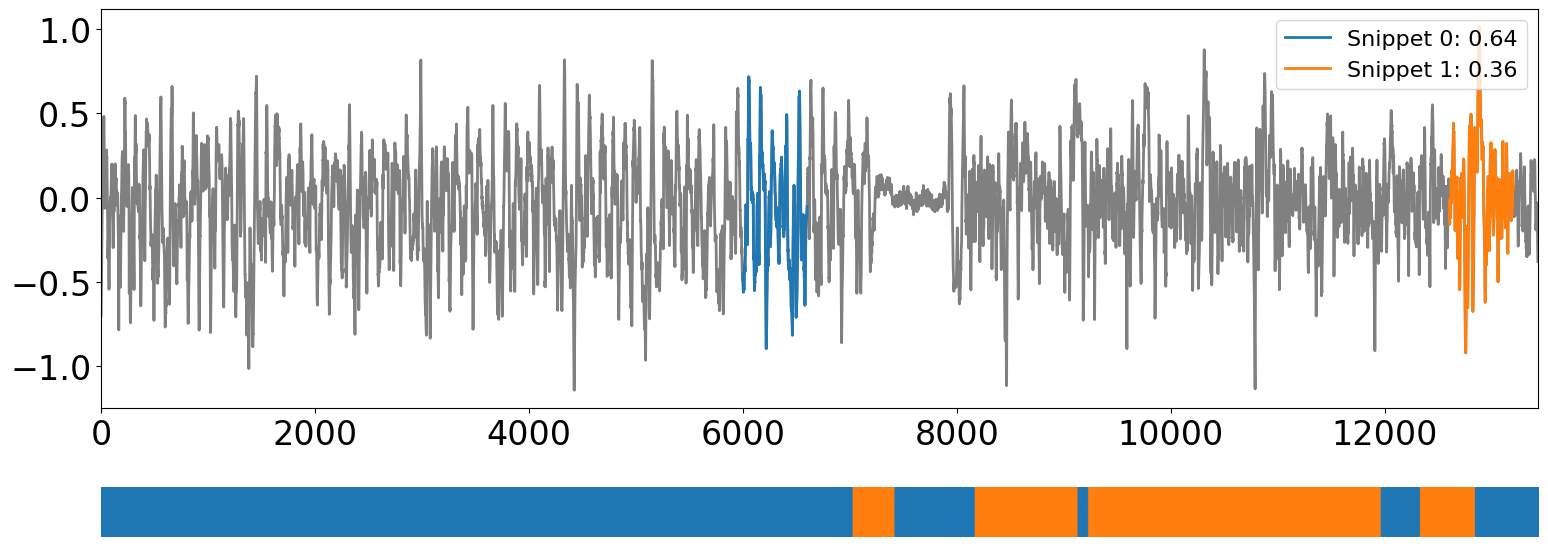

<Axes: >

In [40]:
plot_snippets(ts_y, snp_y)

600


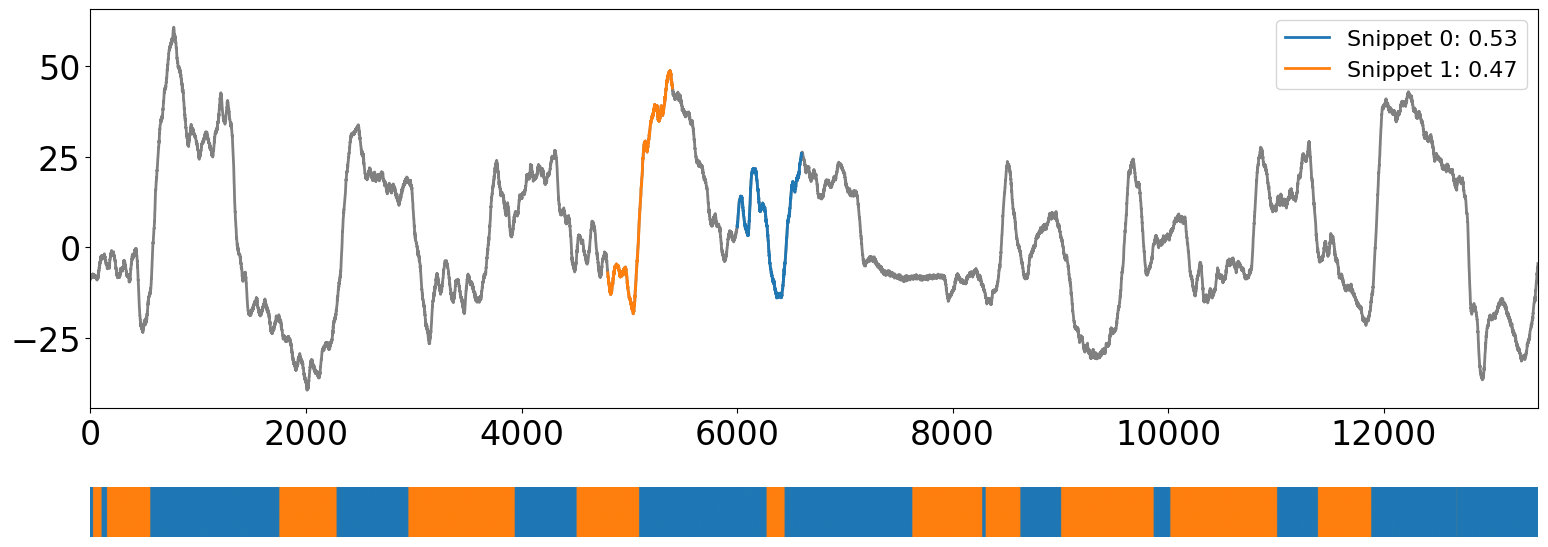

<Axes: >

In [41]:
plot_snippets(ts_z, snp_z)

In [42]:
segments_3d = [snp_x[5], snp_y[5], snp_z[5]]

In [43]:
predictions = []

for segments in segments_3d:
    predicted = np.full_like(activityID, labels[0], dtype=int)
    
    for segment in segments:
        index, start, end = segment
        predicted[start:end] = labels[index]
    
    predictions.append(predicted)

Оцените точность разметки многомерного ряда, используя исходные данные об активностях.

In [45]:
np.mean(activityID[index_min:index_max] == predictions[0][index_min:index_max]) # x

0.9038266697841166

In [46]:
np.mean(activityID[index_min:index_max] == predictions[1][index_min:index_max]) # y

0.8846543527394591

In [47]:
np.mean(activityID[index_min:index_max] == predictions[2][index_min:index_max]) # z

0.6316732912477593

In [48]:
predictions_stack = np.column_stack(predictions)

predicted = np.apply_along_axis(
    lambda x: np.argmax(np.bincount(x)), 
    axis=1, 
    arr=predictions_stack.astype(int)
)

np.mean(activityID[index_min:index_max] == predicted[index_min:index_max])

0.8829397552801808

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Сравните полученные разметки многомерного и одномерного рядов.

Метрика аккуратности осталась на уровне 88%. Для решения данной задачи более эффективно использовать данные гироскопа по оси X, так как в этом случае значение метрики возрастает до 90%.

## Задача 3. Подбор оптимального значения _k_


Разработайте программу, которая выполняет вычисление меры $change$ для различных значений $k$ с помощью алгоритма SnippetFinder. Проведите эксперименты, используя временной ряд из задания 2 (взяв 1 ≤ _k_ ≤ 9).

$Change_k = \frac{ProfileArea_{k-1}}{ProfileArea_k} - 1$

In [53]:
ts_url = './datasets/PAMAP/PAMAP.txt'

ts_origin = np.loadtxt(ts_url)

timestamp = ts_origin[0]
time_range = np.where((timestamp >= 1790.0) & (timestamp <= 1930.0))

ts = ts_origin[12][time_range]

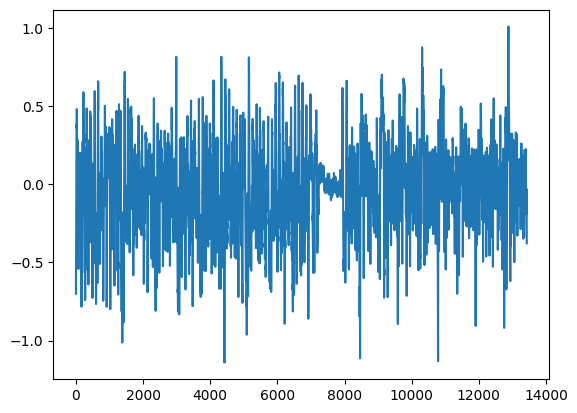

In [54]:
plt.plot(ts)

https://stumpy.readthedocs.io/en/latest/api.html#stumpy.snippets

In [56]:
profile_areas = []
change_values = []

for k in tqdm(range(1, 10)):
    snp = snippets(ts, 600, k, percentage=0.5)
    profile_areas.append(snp[4][-1])
    
    if k > 1:
        change = profile_areas[k-2] / profile_areas[k-1] - 1
        change_values.append(change)
    else:
        change_values.append(0)

100%|█████████████████████████████████████████████| 9/9 [01:09<00:00,  7.68s/it]


Выполните визуализацию результатов экспериментов в следующем виде: отображение столбчатых диаграм со значениями $ProfileArea$ и меры $change$ в зависимости от $k$.

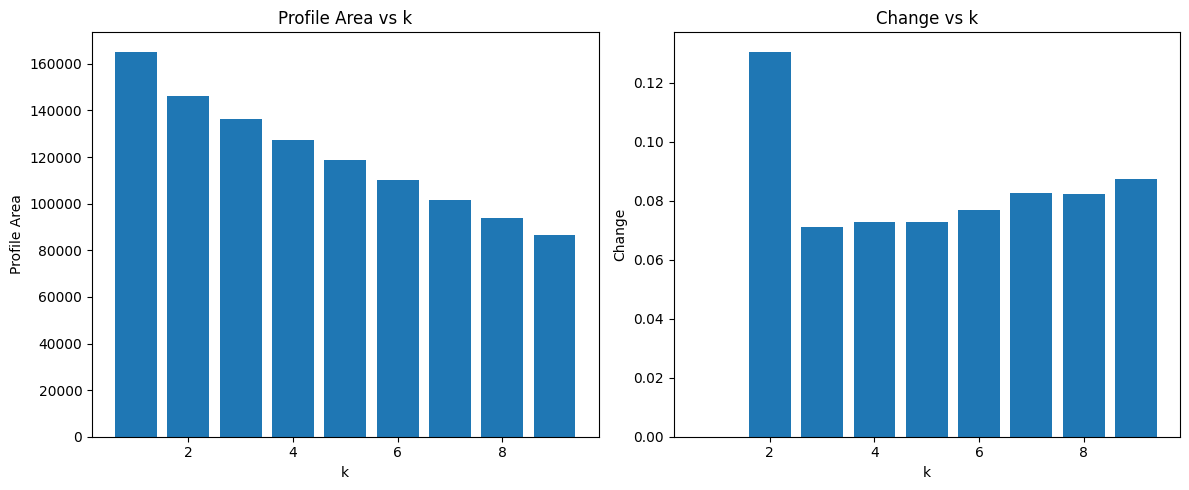

In [58]:
ks = np.arange(1, 10)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.bar(ks, profile_areas)
plt.title("Profile Area vs k")
plt.xlabel("k")
plt.ylabel("Profile Area")

plt.subplot(1, 2, 2)
plt.bar(ks, change_values)
plt.title("Change vs k")
plt.xlabel("k")
plt.ylabel("Change")

plt.tight_layout()
plt.show()

❓ Проанализируйте и изложите содержательный смысл полученных результатов. Какое значение $k$ является наилучшим для используемого временного ряда?

На графике видно, что наибольшее улучшение достигается при переходе от (k = 1) к (k = 2) — значение меры (change) в этот момент максимальное. При дальнейшем увеличении (k) значения (change) становятся небольшими и изменяются незначительно, что указывает на снижение эффекта от добавления новых сниппетов. Уменьшение (ProfileArea) с ростом (k) также подтверждает, что данные становятся лучше объяснены уже при (k = 2), а последующие улучшения несущественны. Оптимальное значение (k) для данного временного ряда — (k = 2).